In [1]:
import sys
import os

# Move one directory up (to project root)
project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Added to PYTHONPATH:", project_root)

Added to PYTHONPATH: /vols/cms/mm1221/geant4sim/scripts/validation_new


In [2]:
import numpy as np
import pandas as pd
import awkward as ak

from src.data_loader.Data_Loader import Data_Loader
from src.models.model_loader import model_loader
from src.clustering.clusterer import clusterer
from src.metrics.build_dataframe import build_dataframe

In [17]:
loader = Data_Loader(
    root="/vols/cms/mm1221/geant4sim/simulations/build/Datasets/Test_EM_11_20/Electron.1005_1006.root",
    split="test",
    max_events=50,
    batch_size=1,
    shuffle=False,
    follow_batch=["x"],
)

### Loading ROOT file: /vols/cms/mm1221/geant4sim/simulations/build/Datasets/Test_EM_11_20/Electron.1005_1006.root
Loaded 25 events


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [7]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cont_config = {
    "task": "contrastive",
    "hidden_dim": 64,
    "num_layers": 3,
    "dropout": 0.01,
    "k": 24,

    "contrastive_dim": 4,
    "coord_dim": 4,
    "path" : "/vols/cms/mm1221/geant4sim/scripts/training/Contrastive/runs/EM_2_10_CD4_Supcon_delta5_t01_New/best_model.pt"
}

oc_config = {
    "task": "oc",
    "hidden_dim": 64,
    "num_layers": 3,
    "dropout": 0.01,
    "k": 24,

    "contrastive_dim": 16,
    "coord_dim": 4,
    "path" : "/vols/cms/mm1221/geant4sim/scripts/training/ObjectCondensation/runs/EM_2_10_CD4_delta5_1/best_model.pt"

}

cont = model_loader(
    config=cont_config,
    device = device
)

oc = model_loader(
    config=oc_config,
    device = device
)

print(f"Model loaded successfully")


Model loaded successfully


In [18]:
import torch.nn.functional as F

all_predictions_cont = []
all_predictions_oc = []
all_energies = []
true_labels = []


for i, data in enumerate(loader):
    data = data.to(device)
    all_energies.append(data.x[:, 3])

    out = cont(data.x, data.x_batch)
    preds = out[0]                     
    #preds = F.normalize(preds, p=2, dim=1)
    all_predictions_cont.append(preds)
    true_labels.append(data.assoc)
    
    beta, cluster_coords, batch = oc(data.x, data.x_batch)
    all_predictions_oc.append(cluster_coords)


    print(i)
    if i == 2:
        break

0
1
2


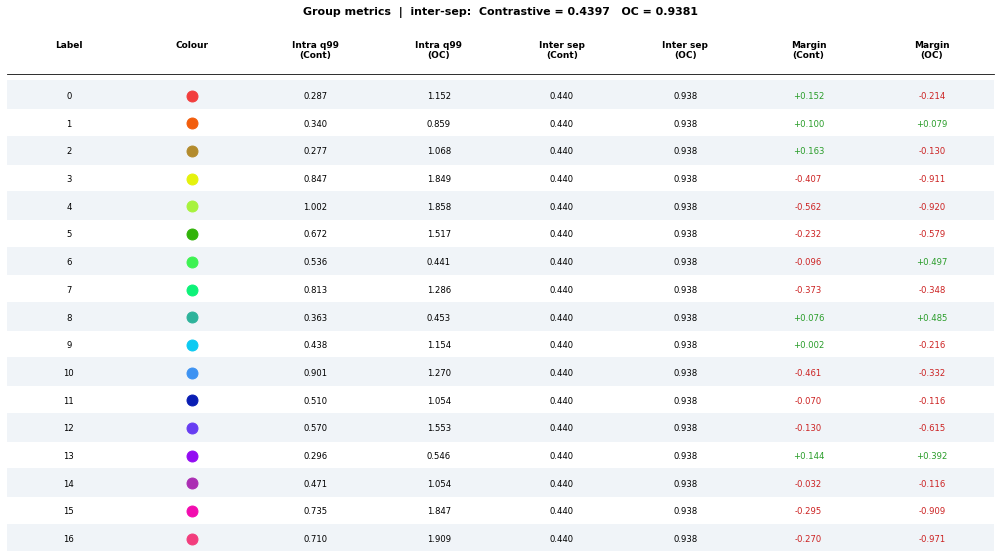


Selected label : 5
  Contrastive  — intra_q99=0.6719  inter_sep=0.4397  margin=-0.2322
  OC           — intra_q99=1.5168  inter_sep=0.9381  margin=-0.5788


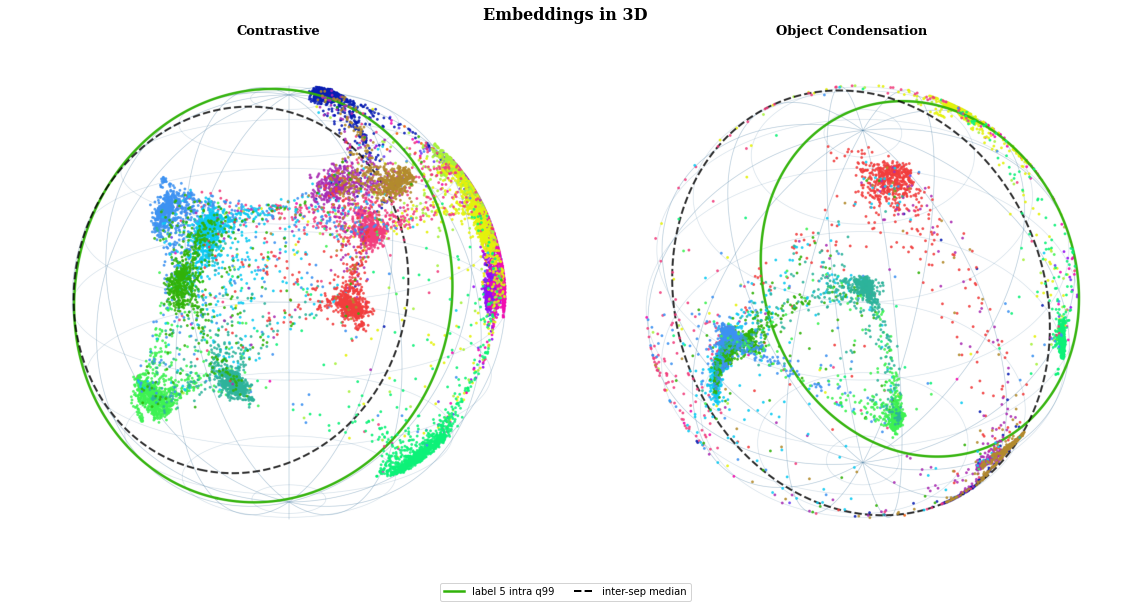

In [43]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from io import BytesIO
from PIL import Image

# =============================================================
# Helpers
# =============================================================

def energy_core_filter(truth_np, en_np, keep_frac=1.00):
    keep_mask = np.zeros(len(truth_np), dtype=bool)
    for label in np.unique(truth_np):
        g_idx  = np.where(truth_np == label)[0]
        g_en   = en_np[g_idx]
        tot    = g_en.sum()
        if tot <= 0:
            keep_mask[g_idx] = True
            continue
        order   = np.argsort(g_en)[::-1]
        cumfrac = np.cumsum(g_en[order]) / tot
        keep_mask[g_idx[order[:np.searchsorted(cumfrac, keep_frac) + 1]]] = True
    return keep_mask

def project(raw_emb, keep_mask):
    emb = F.normalize(raw_emb.detach().cpu().float(), p=2, dim=1)
    return F.normalize(emb[keep_mask][:, :3], p=2, dim=1).numpy()

def distinct_colors(n):
    hues = np.linspace(0, 1, n, endpoint=False)
    cols = []
    for i, h in enumerate(hues):
        s = 0.75 if i % 2 == 0 else 0.95
        v = 0.95 if i % 3 != 2 else 0.70
        cols.append(tuple(mcolors.hsv_to_rgb([h, s, v])))
    return cols

def cosine_dist(a, b):
    return 1.0 - np.einsum("nd,nd->n", a, b)

def intra_q99(emb3, truth, label):
    idx = np.where(truth == label)[0]
    if idx.size < 2:
        return 0.0
    zi = emb3[idx]
    ii, jj = np.triu_indices(len(zi), k=1)
    return float(np.quantile(cosine_dist(zi[ii], zi[jj]), 0.99))

def inter_sep_median(emb3, truth, n_neg=4000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    labels = np.unique(truth)
    by_label = {lab: np.where(truth == lab)[0] for lab in labels}
    d_neg = np.empty(n_neg, dtype=np.float32)
    for t in range(n_neg):
        la, lb = rng.choice(labels, size=2, replace=False)
        a, b   = rng.choice(by_label[la]), rng.choice(by_label[lb])
        d_neg[t] = 1.0 - float(np.dot(emb3[a], emb3[b]))
    return float(np.median(d_neg))

def sphere_circle(center, angular_radius, n=300):
    c = center / np.linalg.norm(center)
    tmp = np.array([1, 0, 0]) if abs(c[0]) < 0.9 else np.array([0, 1, 0])
    u = np.cross(c, tmp);  u /= np.linalg.norm(u)
    v = np.cross(c, u)
    phi = np.linspace(0, 2 * np.pi, n)
    return (np.cos(angular_radius) * c
            + np.sin(angular_radius) * (np.outer(np.cos(phi), u)
                                        + np.outer(np.sin(phi), v)))

# =============================================================
# Data
# =============================================================

i = 2
truth_np  = true_labels[i].detach().cpu().numpy()
en_np     = all_energies[i].detach().cpu().numpy()
keep_mask = energy_core_filter(truth_np, en_np)
truth     = truth_np[keep_mask]

emb3_cont = project(all_predictions_cont[i], keep_mask)
emb3_oc   = project(all_predictions_oc[i],   keep_mask)

all_labels   = np.unique(truth)
colors       = distinct_colors(len(all_labels))
label_colors = {lab: colors[idx] for idx, lab in enumerate(all_labels)}

# sphere grid
phi_g, theta_g = np.meshgrid(np.linspace(0, np.pi, 40),
                              np.linspace(0, 2 * np.pi, 80))
sx = np.sin(phi_g) * np.cos(theta_g)
sy = np.sin(phi_g) * np.sin(theta_g)
sz = np.cos(phi_g)

# =============================================================
# Compute metrics for ALL groups
# =============================================================

inter_cont = inter_sep_median(emb3_cont, truth, rng=np.random.default_rng(123))
inter_oc   = inter_sep_median(emb3_oc,   truth, rng=np.random.default_rng(123))

group_metrics = {}
for lab in all_labels:
    q99_c = intra_q99(emb3_cont, truth, lab)
    q99_o = intra_q99(emb3_oc,   truth, lab)
    group_metrics[lab] = {
        "q99_cont":    q99_c,
        "q99_oc":      q99_o,
        "margin_cont": inter_cont - q99_c,
        "margin_oc":   inter_oc   - q99_o,
    }

# =============================================================
# Notebook-only colour key + metrics table
# =============================================================

n = len(all_labels)
col_headers = [
    "Label", "Colour",
    "Intra q99\n(Cont)", "Intra q99\n(OC)",
    "Inter sep\n(Cont)", "Inter sep\n(OC)",
    "Margin\n(Cont)",    "Margin\n(OC)",
]
n_cols = len(col_headers)
col_xs = [(ci + 0.5) / n_cols for ci in range(n_cols)]

fig_leg, ax_leg = plt.subplots(figsize=(14, n * 0.38 + 1.4))
ax_leg.set_axis_off()
ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1)

# header row
for ci, ch in enumerate(col_headers):
    ax_leg.text(col_xs[ci], 0.97, ch,
                fontsize=9, fontweight="bold",
                va="top", ha="center", transform=ax_leg.transAxes)

# divider under header
y_div = 0.97 - 1.2 / (n + 2)
ax_leg.plot([0, 1], [y_div, y_div], color="black", lw=0.8,
            transform=ax_leg.transAxes, clip_on=False)

for ri, lab in enumerate(all_labels):
    m   = group_metrics[lab]
    col = label_colors[lab]
    y   = 0.97 - (ri + 2.0) / (n + 2)

    row_vals = [
        f"{lab}", "",
        f"{m['q99_cont']:.3f}",
        f"{m['q99_oc']:.3f}",
        f"{inter_cont:.3f}",
        f"{inter_oc:.3f}",
        f"{m['margin_cont']:+.3f}",
        f"{m['margin_oc']:+.3f}",
    ]

    # alternating row shading
    if ri % 2 == 0:
        ax_leg.axhspan(y - 0.45 / (n + 2), y + 0.55 / (n + 2),
                       color="#f0f4f8", zorder=0,
                       transform=ax_leg.transAxes)

    for ci, val in enumerate(row_vals):
        if ci == 1:
            ax_leg.scatter(col_xs[ci], y, color=col, s=120,
                           transform=ax_leg.transAxes,
                           clip_on=False, zorder=5)
        else:
            txt_col = "black"
            if ci == 6:
                txt_col = "#2a9d2a" if m["margin_cont"] >= 0 else "#cc2222"
            if ci == 7:
                txt_col = "#2a9d2a" if m["margin_oc"]   >= 0 else "#cc2222"
            ax_leg.text(col_xs[ci], y, val,
                        transform=ax_leg.transAxes,
                        fontsize=8.5, va="center", ha="center",
                        color=txt_col)

ax_leg.set_title(
    f"Group metrics  |  inter-sep:  Contrastive = {inter_cont:.4f}   "
    f"OC = {inter_oc:.4f}",
    fontsize=11, fontweight="bold", pad=10
)
plt.tight_layout()
plt.show()   # notebook only — never saved to PDF

# =============================================================
# Selected cluster to highlight
# =============================================================

SELECTED_LABEL = 5   # ← change this after reading the table above

q99_c_sel = group_metrics[SELECTED_LABEL]["q99_cont"]
q99_o_sel = group_metrics[SELECTED_LABEL]["q99_oc"]

print(f"\nSelected label : {SELECTED_LABEL}")
print(f"  Contrastive  — intra_q99={q99_c_sel:.4f}  "
      f"inter_sep={inter_cont:.4f}  "
      f"margin={inter_cont - q99_c_sel:+.4f}")
print(f"  OC           — intra_q99={q99_o_sel:.4f}  "
      f"inter_sep={inter_oc:.4f}  "
      f"margin={inter_oc - q99_o_sel:+.4f}")

# =============================================================
# Render
# =============================================================

def render_sphere(emb3, truth, label_colors, title,
                  selected_label, q99, inter_sep,
                  elev=35, azim=0, dpi=150):

    fig = plt.figure(figsize=(14, 14), facecolor="white")
    ax  = fig.add_subplot(111, projection="3d")
    ax.view_init(elev=elev, azim=azim)

    elev_r, azim_r = np.radians(elev), np.radians(azim)
    cam = np.array([
        np.cos(elev_r) * np.cos(azim_r),
        np.cos(elev_r) * np.sin(azim_r),
        np.sin(elev_r),
    ])

    # latitude lines
    for lat in np.linspace(-80, 80, 9):
        r   = np.cos(np.radians(lat))
        z_l = np.sin(np.radians(lat))
        phi = np.linspace(0, 2 * np.pi, 200)
        ax.plot(r * np.cos(phi), r * np.sin(phi),
                np.full_like(phi, z_l),
                color="#4a7fa5", lw=0.5, alpha=0.30)

    # longitude lines
    for lon in np.linspace(0, 360, 13)[:-1]:
        theta = np.linspace(0, 2 * np.pi, 200)
        ax.plot(np.cos(np.radians(lon)) * np.sin(theta),
                np.sin(np.radians(lon)) * np.sin(theta),
                np.cos(theta),
                color="#4a7fa5", lw=0.5, alpha=0.30)

    # front-face points
    for lab in np.unique(truth):
        mask  = (truth == lab)
        pts   = emb3[mask]
        front = (pts @ cam) > 0
        pts_f = pts[front]
        if pts_f.shape[0] == 0:
            continue
        ax.scatter(pts_f[:, 0], pts_f[:, 1], pts_f[:, 2],
                   color=label_colors[lab], s=8, alpha=0.85,
                   linewidths=0, zorder=5)

    # selected cluster rings
    sel_idx  = np.where(truth == selected_label)[0]
    centroid = emb3[sel_idx].mean(axis=0)
    centroid /= np.linalg.norm(centroid)
    sel_col  = label_colors[selected_label]

    ang_q99  = float(np.arccos(np.clip(1.0 - q99,      -1, 1)))
    ang_inter = float(np.arccos(np.clip(1.0 - inter_sep, -1, 1)))

    ring_q99  = sphere_circle(centroid, ang_q99)
    ring_inter = sphere_circle(centroid, ang_inter)

    ax.plot(ring_q99[:, 0], ring_q99[:, 1], ring_q99[:, 2],
            color=sel_col, lw=2.5, ls="-", alpha=0.95, zorder=10)
    ax.plot(ring_inter[:, 0], ring_inter[:, 1], ring_inter[:, 2],
            color="black", lw=2.0, ls="--", alpha=0.80, zorder=10)

    ax.scatter(*centroid, color=sel_col, s=80, marker="x",
               linewidths=2, zorder=11)

    ax.set_axis_off()
    ax.grid(False)
    ax.xaxis.pane.set_visible(False)
    ax.yaxis.pane.set_visible(False)
    ax.zaxis.pane.set_visible(False)
    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
    try:
        ax.set_box_aspect([1, 1, 1])
    except Exception:
        pass

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=dpi,
                bbox_inches="tight", facecolor="white", pad_inches=-1.5)
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf).copy()
    buf.close()
    img = img.crop(img.getbbox())
    return img, title

# ── angles — tune independently ────────────────────────────────
ELEV_CONT, AZIM_CONT = 200, 60
ELEV_OC,   AZIM_OC   = 40, 200

img_cont, title_cont = render_sphere(
    emb3_cont, truth, label_colors, "Contrastive",
    SELECTED_LABEL, q99_c_sel, inter_cont,
    elev=ELEV_CONT, azim=AZIM_CONT)

img_oc, title_oc = render_sphere(
    emb3_oc, truth, label_colors, "Object Condensation",
    SELECTED_LABEL, q99_o_sel, inter_oc,
    elev=ELEV_OC, azim=AZIM_OC)

# =============================================================
# Composite — saved to PDF
# =============================================================

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor("white")
fig.suptitle("Embeddings in 3D", fontsize=16, fontweight="bold",
             fontfamily="serif", y=1.01)

for ax, img, title in [(axes[0], img_cont, title_cont),
                        (axes[1], img_oc,   title_oc)]:
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight="bold",
                 fontfamily="serif", pad=6)
    ax.axis("off")

legend_els = [
    Line2D([0], [0], color=label_colors[SELECTED_LABEL],
           lw=2.5, ls="-",  label=f"label {SELECTED_LABEL} intra q99"),
    Line2D([0], [0], color="black",
           lw=2.0, ls="--", label="inter-sep median"),
]
fig.legend(handles=legend_els, loc="lower center",
           ncol=2, fontsize=10, framealpha=0.85,
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout(pad=0.5)
plt.savefig("embeddings_3d.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

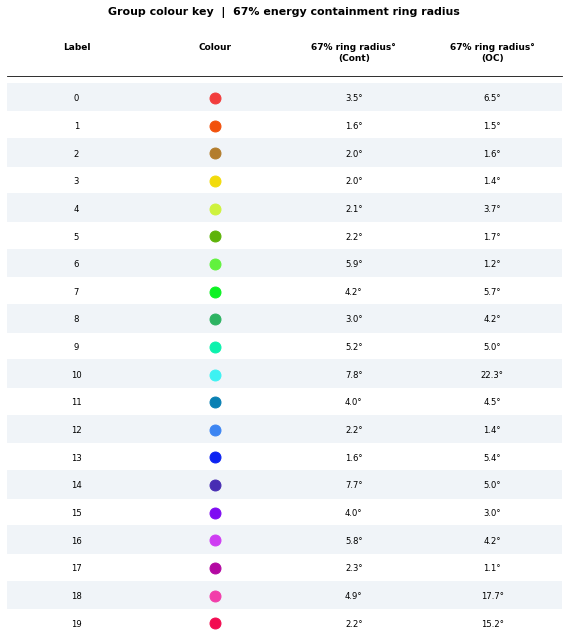

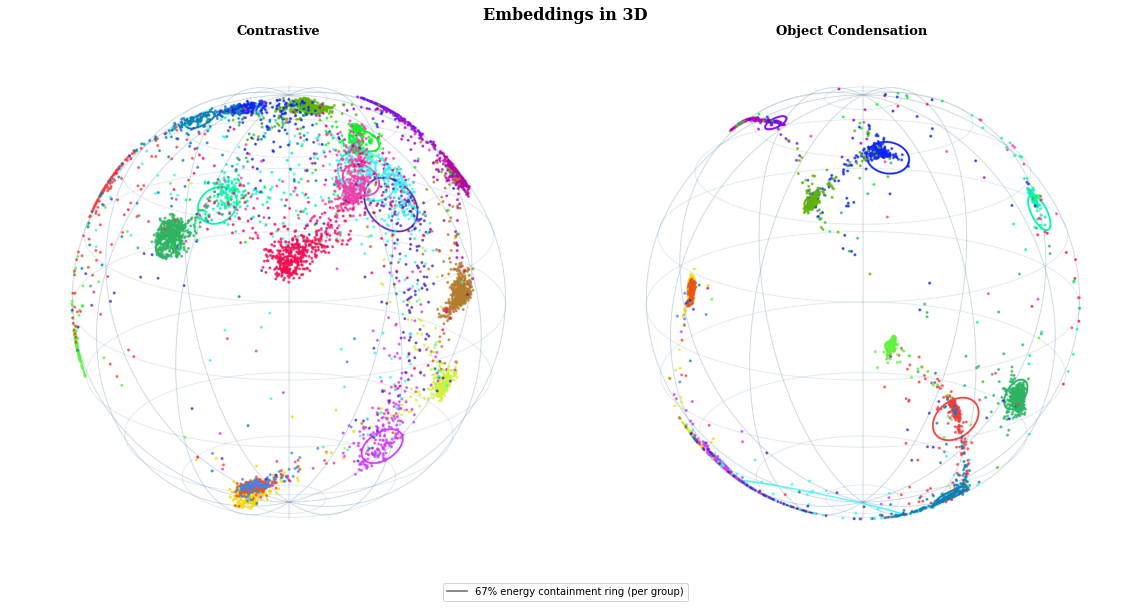

In [21]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from io import BytesIO
from PIL import Image

# =============================================================
# Helpers
# =============================================================

def energy_core_filter(truth_np, en_np, keep_frac=0.95):
    keep_mask = np.zeros(len(truth_np), dtype=bool)
    for label in np.unique(truth_np):
        g_idx  = np.where(truth_np == label)[0]
        g_en   = en_np[g_idx]
        tot    = g_en.sum()
        if tot <= 0:
            keep_mask[g_idx] = True
            continue
        order   = np.argsort(g_en)[::-1]
        cumfrac = np.cumsum(g_en[order]) / tot
        keep_mask[g_idx[order[:np.searchsorted(cumfrac, keep_frac) + 1]]] = True
    return keep_mask

def project(raw_emb, keep_mask):
    emb = F.normalize(raw_emb.detach().cpu().float(), p=2, dim=1)
    return F.normalize(emb[keep_mask][:, :3], p=2, dim=1).numpy()

def distinct_colors(n):
    hues = np.linspace(0, 1, n, endpoint=False)
    cols = []
    for i, h in enumerate(hues):
        s = 0.75 if i % 2 == 0 else 0.95
        v = 0.95 if i % 3 != 2 else 0.70
        cols.append(tuple(mcolors.hsv_to_rgb([h, s, v])))
    return cols

def energy_containment_ring_radius(emb3, en_np, truth, label, frac=0.67):
    """
    For a group, compute the angular radius (radians) around the
    energy-weighted centroid that contains `frac` of the group's total energy.
    Strategy:
      1. Compute energy-weighted centroid on S²
      2. Compute angular distance of each node from centroid
      3. Sort by angular distance ascending
      4. Walk outward until cumulative energy >= frac * total
    """
    idx    = np.where(truth == label)[0]
    pts    = emb3[idx]
    en     = en_np[idx].clip(0)
    tot    = en.sum()

    if tot <= 0 or len(idx) < 2:
        return None, None

    # energy-weighted centroid
    centroid = (pts * en[:, None]).sum(axis=0)
    norm = np.linalg.norm(centroid)
    if norm < 1e-9:
        centroid = pts.mean(axis=0)
        norm = np.linalg.norm(centroid)
    centroid /= norm

    # angular distance of each node from centroid
    dots     = np.clip(pts @ centroid, -1, 1)
    ang_dist = np.arccos(dots)           # radians

    # sort by angular distance, accumulate energy outward
    order   = np.argsort(ang_dist)
    cumfrac = np.cumsum(en[order]) / tot
    k       = int(np.searchsorted(cumfrac, frac))
    k       = min(k, len(order) - 1)

    ang_radius = float(ang_dist[order[k]])
    return centroid, ang_radius

def sphere_circle(center, angular_radius, n=300):
    c = center / np.linalg.norm(center)
    tmp = np.array([1, 0, 0]) if abs(c[0]) < 0.9 else np.array([0, 1, 0])
    u = np.cross(c, tmp);  u /= np.linalg.norm(u)
    v = np.cross(c, u)
    phi = np.linspace(0, 2 * np.pi, n)
    return (np.cos(angular_radius) * c
            + np.sin(angular_radius) * (np.outer(np.cos(phi), u)
                                        + np.outer(np.sin(phi), v)))

# =============================================================
# Data
# =============================================================

i = 0
truth_np  = true_labels[i].detach().cpu().numpy()
en_np     = all_energies[i].detach().cpu().numpy()
keep_mask = energy_core_filter(truth_np, en_np)
truth     = truth_np[keep_mask]
en_kept   = en_np[keep_mask]

emb3_cont = project(all_predictions_cont[i], keep_mask)
emb3_oc   = project(all_predictions_oc[i],   keep_mask)

all_labels   = np.unique(truth)
colors       = distinct_colors(len(all_labels))
label_colors = {lab: colors[idx] for idx, lab in enumerate(all_labels)}

# sphere grid
phi_g, theta_g = np.meshgrid(np.linspace(0, np.pi, 40),
                              np.linspace(0, 2 * np.pi, 80))
sx = np.sin(phi_g) * np.cos(theta_g)
sy = np.sin(phi_g) * np.sin(theta_g)
sz = np.cos(phi_g)

# =============================================================
# Pre-compute 67% energy rings for every group, both models
# =============================================================

rings_cont = {}
rings_oc   = {}
for lab in all_labels:
    rings_cont[lab] = energy_containment_ring_radius(
        emb3_cont, en_kept, truth, lab, frac=0.67)
    rings_oc[lab]   = energy_containment_ring_radius(
        emb3_oc,   en_kept, truth, lab, frac=0.67)

# =============================================================
# Notebook colour key
# =============================================================

n = len(all_labels)
col_headers = ["Label", "Colour",
               "67% ring radius°\n(Cont)", "67% ring radius°\n(OC)"]
n_cols = len(col_headers)
col_xs = [(ci + 0.5) / n_cols for ci in range(n_cols)]

fig_leg, ax_leg = plt.subplots(figsize=(8, n * 0.38 + 1.4))
ax_leg.set_axis_off()
ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1)

for ci, ch in enumerate(col_headers):
    ax_leg.text(col_xs[ci], 0.97, ch, fontsize=9, fontweight="bold",
                va="top", ha="center", transform=ax_leg.transAxes)

y_div = 0.97 - 1.2 / (n + 2)
ax_leg.plot([0, 1], [y_div, y_div], color="black", lw=0.8,
            transform=ax_leg.transAxes, clip_on=False)

for ri, lab in enumerate(all_labels):
    col = label_colors[lab]
    y   = 0.97 - (ri + 2.0) / (n + 2)

    _, r_c = rings_cont[lab]
    _, r_o = rings_oc[lab]
    r_c_deg = f"{np.degrees(r_c):.1f}°" if r_c is not None else "—"
    r_o_deg = f"{np.degrees(r_o):.1f}°" if r_o is not None else "—"

    if ri % 2 == 0:
        ax_leg.axhspan(y - 0.45 / (n + 2), y + 0.55 / (n + 2),
                       color="#f0f4f8", zorder=0,
                       transform=ax_leg.transAxes)

    row_vals = [f"{lab}", "", r_c_deg, r_o_deg]
    for ci, val in enumerate(row_vals):
        if ci == 1:
            ax_leg.scatter(col_xs[ci], y, color=col, s=120,
                           transform=ax_leg.transAxes,
                           clip_on=False, zorder=5)
        else:
            ax_leg.text(col_xs[ci], y, val,
                        transform=ax_leg.transAxes,
                        fontsize=8.5, va="center", ha="center", color="black")

ax_leg.set_title("Group colour key  |  67% energy containment ring radius",
                 fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()   # notebook only

# =============================================================
# Render
# =============================================================

def render_sphere(emb3, truth, en_kept, label_colors, rings,
                  title, elev=35, azim=0, dpi=150):

    fig = plt.figure(figsize=(14, 14), facecolor="white")
    ax  = fig.add_subplot(111, projection="3d")
    ax.view_init(elev=elev, azim=azim)

    elev_r, azim_r = np.radians(elev), np.radians(azim)
    cam = np.array([
        np.cos(elev_r) * np.cos(azim_r),
        np.cos(elev_r) * np.sin(azim_r),
        np.sin(elev_r),
    ])

    # latitude lines
    for lat in np.linspace(-80, 80, 9):
        r   = np.cos(np.radians(lat))
        z_l = np.sin(np.radians(lat))
        phi = np.linspace(0, 2 * np.pi, 200)
        ax.plot(r * np.cos(phi), r * np.sin(phi),
                np.full_like(phi, z_l),
                color="#4a7fa5", lw=0.5, alpha=0.30)

    # longitude lines
    for lon in np.linspace(0, 360, 13)[:-1]:
        theta = np.linspace(0, 2 * np.pi, 200)
        ax.plot(np.cos(np.radians(lon)) * np.sin(theta),
                np.sin(np.radians(lon)) * np.sin(theta),
                np.cos(theta),
                color="#4a7fa5", lw=0.5, alpha=0.30)

    # front-face scatter
    for lab in np.unique(truth):
        mask  = (truth == lab)
        pts   = emb3[mask]
        front = (pts @ cam) > 0
        pts_f = pts[front]
        if pts_f.shape[0] == 0:
            continue
        ax.scatter(pts_f[:, 0], pts_f[:, 1], pts_f[:, 2],
                   color=label_colors[lab], s=8, alpha=0.85,
                   linewidths=0, zorder=5)

    # 67% energy containment ring per group — front face only
    for lab in np.unique(truth):
        centroid, ang_rad = rings[lab]
        if centroid is None:
            continue
        col      = label_colors[lab]
        ring_pts = sphere_circle(centroid, ang_rad)   # (300, 3)

        # only keep ring points on the visible hemisphere
        front    = (ring_pts @ cam) > 0
        ring_pts = ring_pts[front]
        if ring_pts.shape[0] == 0:
            continue

        # plot as scatter dots rather than a line so gaps don't draw
        # connecting lines across the hidden side
        ax.scatter(ring_pts[:, 0], ring_pts[:, 1], ring_pts[:, 2],
                   color=col, s=3, alpha=0.90, linewidths=0, zorder=8)

    ax.set_axis_off()
    ax.grid(False)
    ax.xaxis.pane.set_visible(False)
    ax.yaxis.pane.set_visible(False)
    ax.zaxis.pane.set_visible(False)
    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
    try:
        ax.set_box_aspect([1, 1, 1])
    except Exception:
        pass

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=dpi,
                bbox_inches="tight", facecolor="white", pad_inches=-1.5)
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf).copy()
    buf.close()
    img = img.crop(img.getbbox())
    return img, title

# ── angles ─────────────────────────────────────────────────────
ELEV_CONT, AZIM_CONT = 200, 30
ELEV_OC,   AZIM_OC   = 200, 30

img_cont, title_cont = render_sphere(
    emb3_cont, truth, en_kept, label_colors, rings_cont,
    "Contrastive", elev=ELEV_CONT, azim=AZIM_CONT)

img_oc, title_oc = render_sphere(
    emb3_oc, truth, en_kept, label_colors, rings_oc,
    "Object Condensation", elev=ELEV_OC, azim=AZIM_OC)

# =============================================================
# Composite — saved to PDF
# =============================================================

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor("white")
fig.suptitle("Embeddings in 3D", fontsize=16, fontweight="bold",
             fontfamily="serif", y=1.01)

for ax, img, title in [(axes[0], img_cont, title_cont),
                        (axes[1], img_oc,   title_oc)]:
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight="bold",
                 fontfamily="serif", pad=6)
    ax.axis("off")

fig.legend(
    handles=[Line2D([0], [0], color="gray", lw=1.8, ls="-",
                    label="67% energy containment ring (per group)")],
    loc="lower center", fontsize=10, framealpha=0.85,
    bbox_to_anchor=(0.5, -0.03)
)

plt.tight_layout(pad=0.5)
plt.savefig("embeddings_3d.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()